# Start

In [90]:
from ldst import waves_residual_split, reconstruct_y, normalize_torch

import torch
import torch.nn.functional as F
from torchvision import transforms
import tqdm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

device = 'cuda'


# Definitions

# Do things

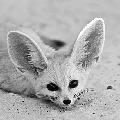

In [91]:
path_image = 'fenek.png'
oi = Image.open(path_image)
oi


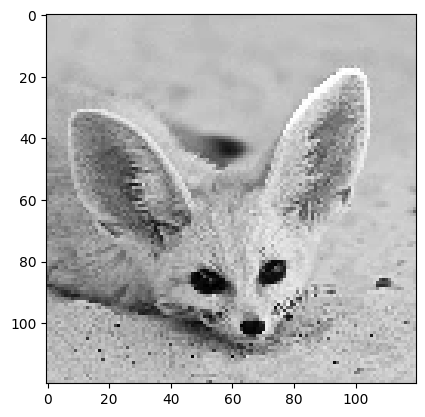

In [92]:
oi = transforms.ToTensor()(oi).unsqueeze(0).to(device)
plt.imshow(oi[0][0].cpu().numpy(), cmap='gray')

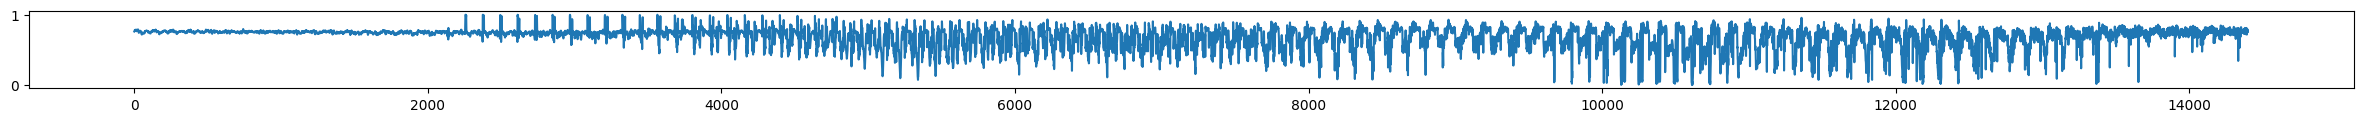

In [93]:


average_value = oi.mean()
wavelen = 60
# rolling_window = 241
rolling_window = oi.shape[2] // 2
rolling_window = rolling_window if rolling_window % 2 else rolling_window + 1
oi_flat = oi.flatten()
n = oi_flat.numel()
x = torch.arange(n).to(device)


plt.figure(figsize=(30, 1))
plt.plot(x.cpu(), oi_flat.cpu())

In [94]:
num_waves = 3
learning_rate = 0.5

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00,  8.29it/s]


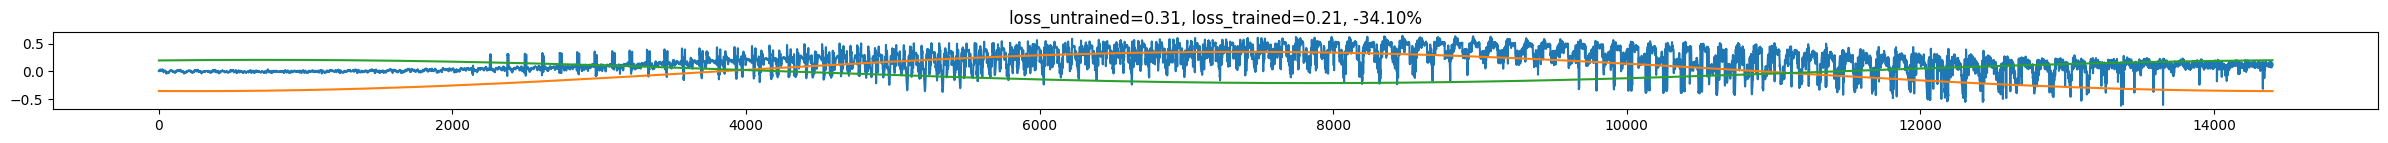

100%|██████████| 5/5 [00:00<00:00,  8.30it/s]


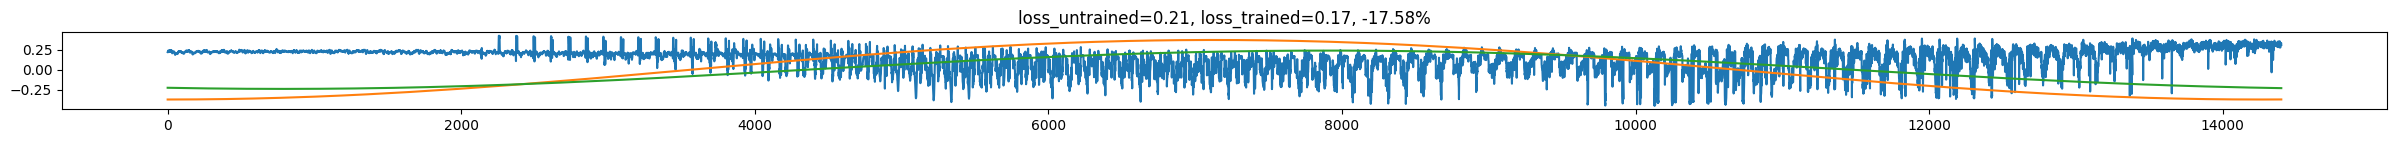

100%|██████████| 5/5 [00:00<00:00,  9.23it/s]


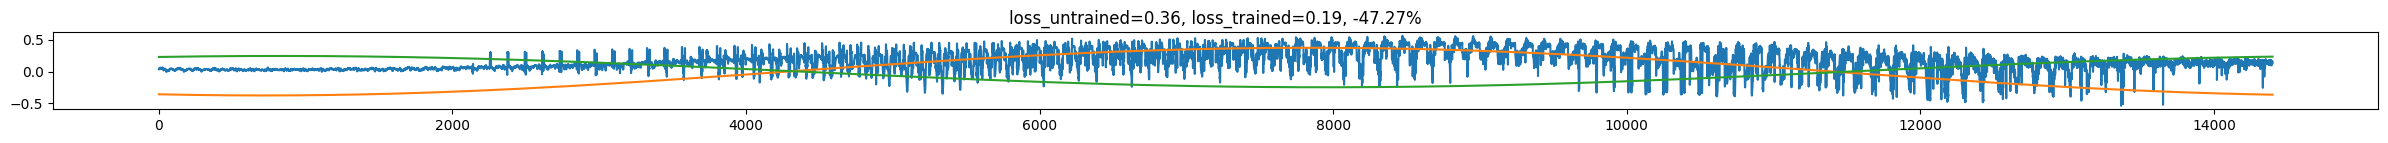

In [95]:
waves_params, residual = waves_residual_split(x_tensor=x, y_tensor=oi_flat, num_waves=num_waves, rolling_window=rolling_window, learning_rate=learning_rate, device=device, wavelen=wavelen, plot=True)

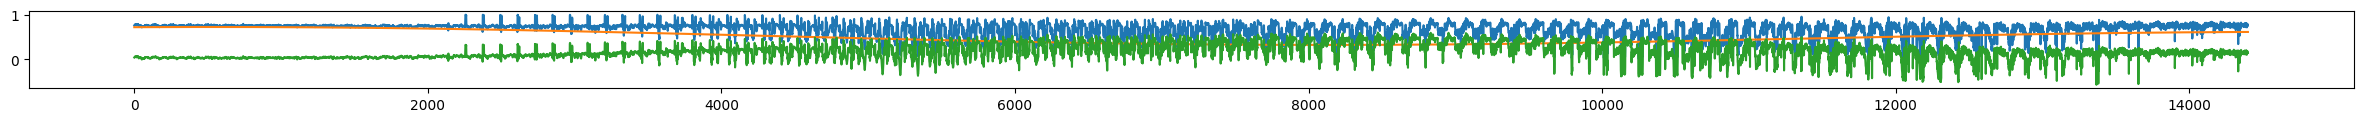

In [96]:
approximation = reconstruct_y(x, torch.zeros_like(oi_flat), waves_params)
residual = oi_flat - approximation
plt.figure(figsize=(30, 1))
plt.plot(x.cpu(), oi_flat.cpu())
plt.plot(x.cpu(), approximation.detach().cpu().numpy())
plt.plot(x.cpu(), residual.detach().cpu().numpy())
plt.show()

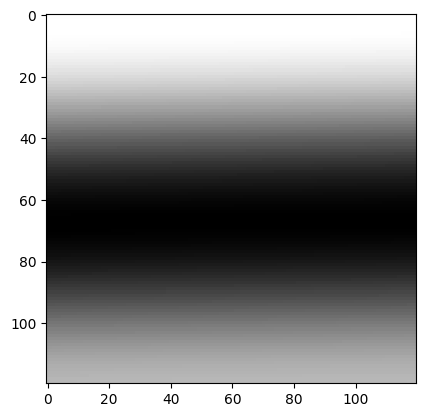

In [97]:
approx_norm = normalize_torch(approximation.reshape(oi.shape)[0][0])
plt.imshow(approx_norm.cpu(), cmap='gray')

In [98]:
wavelen = oi.shape[3]
t_oi_flat = oi.squeeze().T.flatten()
t_waves_params, t_residual = waves_residual_split(x_tensor=x, y_tensor=t_oi_flat, num_waves=num_waves, rolling_window=rolling_window, learning_rate=learning_rate, device=device, wavelen=wavelen, plot=False)

100%|██████████| 5/5 [00:00<00:00,  8.91it/s]


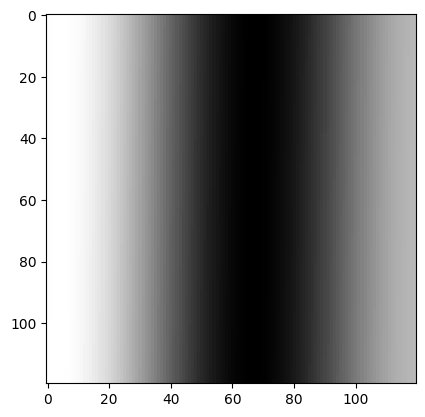

In [99]:
t_approximation = reconstruct_y(x, torch.zeros_like(t_oi_flat), waves_params)
t_residual = t_oi_flat - t_approximation
t_approx_norm = normalize_torch(t_approximation.reshape(oi.squeeze().shape)).T
plt.imshow(t_approx_norm.cpu(), cmap='gray')

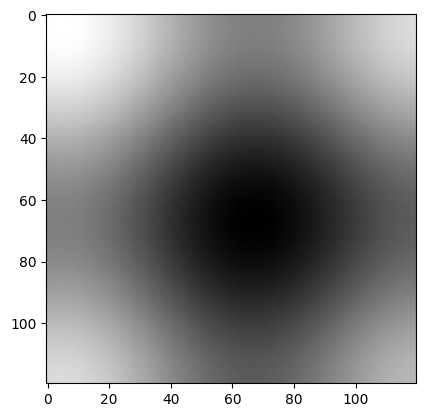

In [100]:
approx_combo = (approx_norm + t_approx_norm) / 2
plt.imshow(approx_combo.cpu(), cmap='gray')

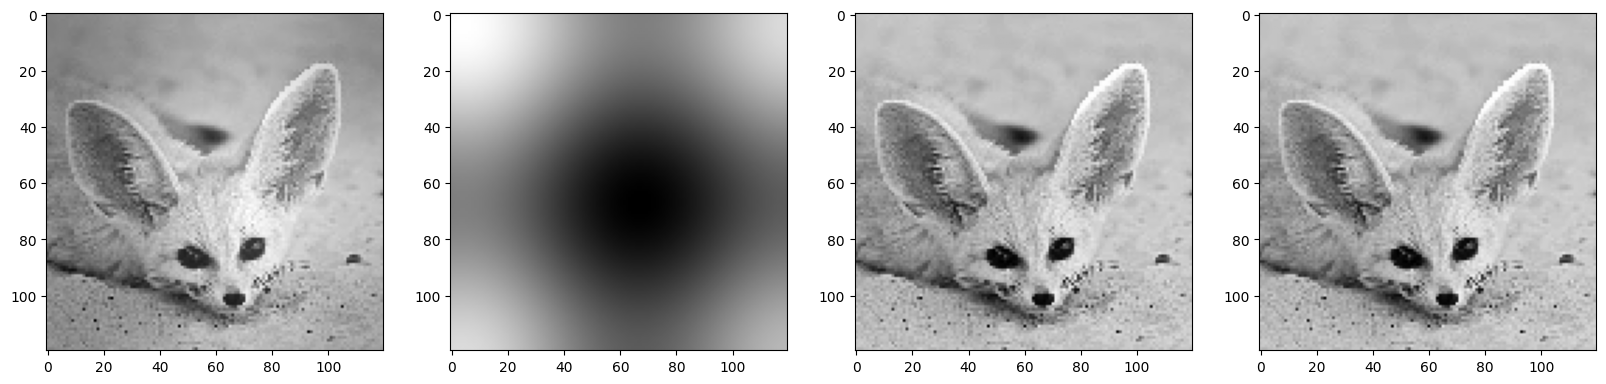

In [101]:
fig, ax = plt.subplots(1, 4, figsize=(20, 6))
ax[0].imshow((residual.reshape(oi.squeeze().shape).cpu() + t_residual.reshape(oi.squeeze().shape).T.cpu()) / 2, cmap='gray')
ax[1].imshow((approximation.reshape(oi.squeeze().shape).cpu() + t_approximation.reshape(oi.squeeze().shape).T.cpu()) / 2, cmap='gray')
ax[2].imshow(residual.reshape(oi.squeeze().shape).cpu() + approximation.reshape(oi.squeeze().shape).cpu(), cmap='gray')
ax[3].imshow(oi.squeeze().cpu(), cmap='gray')

In [102]:
(oi.squeeze() - approx_combo).abs().mean()

tensor(0.2785, device='cuda:0')

In [103]:
(oi.squeeze() - approx_norm).abs().mean()

tensor(0.3210, device='cuda:0')

In [104]:
(oi.squeeze() - t_approx_norm).abs().mean()

tensor(0.3735, device='cuda:0')

In [105]:
(oi.squeeze() - oi.squeeze().mean()).abs().mean()

tensor(0.1174, device='cuda:0')

# End